# Met Office vs. ERA5 data

In [8]:
from datetime import datetime

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

from earth2studio.data import ARCO

import os, sys

if '__vsc_ipynb_file__' in dir():
    sys.path.insert(0, os.path.dirname(__vsc_ipynb_file__))
else:
    sys.path.insert(0, os.getcwd())

from src.metoffice_source import MetOfficeAtlasSource
from src.metoffice_atmospheric import MetOfficePlanetaryComputer
from src.util import roll_lon

In [5]:
# from earth2studio.models.px import Atlas
# package = Atlas.load_default_package()
# model = Atlas.load_model(package)
# atlas_input = model.input_coords()['variable']

# inlined to avoid loading the model
atlas_input = np.array(['u10m', 'v10m', 'u100m', 'v100m', 't2m', 'sp', 'msl', 'tcwv',
       'u50', 'u100', 'u150', 'u200', 'u250', 'u300', 'u400', 'u500',
       'u600', 'u700', 'u850', 'u925', 'u1000', 'v50', 'v100', 'v150',
       'v200', 'v250', 'v300', 'v400', 'v500', 'v600', 'v700', 'v850',
       'v925', 'v1000', 'z50', 'z100', 'z150', 'z200', 'z250', 'z300',
       'z400', 'z500', 'z600', 'z700', 'z850', 'z925', 'z1000', 't50',
       't100', 't150', 't200', 't250', 't300', 't400', 't500', 't600',
       't700', 't850', 't925', 't1000', 'q50', 'q100', 'q150', 'q200',
       'q250', 'q300', 'q400', 'q500', 'q600', 'q700', 'q850', 'q925',
       'q1000', 'sst', 'tp'], dtype='<U5')

In [ ]:
mo_pc = MetOfficePlanetaryComputer()
full_res = mo_pc(
    time = datetime(2026,2,1),
    variable = ['wind_speed_at_10m']
)
full_res

Fetching met-office-global-deterministic-pressure:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching met-office-global-deterministic-pressure: 100%|██████████| 1/1 [00:05<00:00,  5.13s/it]


<xarray.DataArray (time: 1, variable: 1, lat: 1920, lon: 2560)> Size: 20MB
array([[[[7.5625, 7.5625, 7.5625, ..., 7.5625, 7.5625, 7.5625],
         [7.1875, 7.1875, 7.1875, ..., 7.1875, 7.1875, 7.1875],
         [6.4375, 6.4375, 6.4375, ..., 6.4375, 6.4375, 6.4375],
         ...,
         [7.75  , 7.75  , 7.75  , ..., 7.75  , 7.75  , 7.75  ],
         [7.625 , 7.625 , 7.625 , ..., 7.625 , 7.625 , 7.625 ],
         [7.625 , 7.625 , 7.625 , ..., 7.625 , 7.625 , 7.625 ]]]],
      dtype=float32)
Coordinates:
  * time      (time) datetime64[us] 8B 2026-02-01
  * variable  (variable) <U17 68B 'wind_speed_at_10m'
  * lat       (lat) float32 8kB -89.95 -89.86 -89.77 ... 89.77 89.86 89.95
  * lon       (lon) float32 10kB 0.07031 0.2109 0.3516 ... 359.6 359.8 359.9

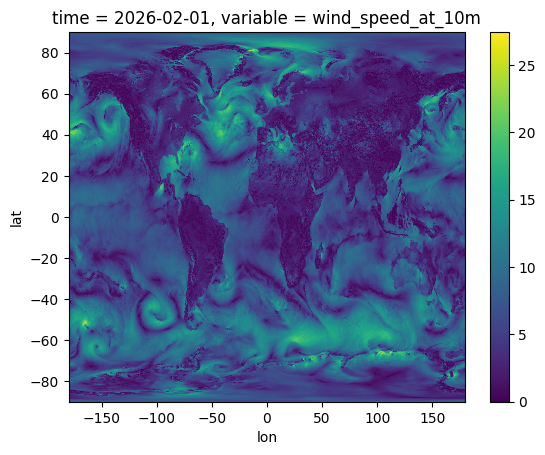

In [14]:
full_res.pipe(roll_lon).squeeze().plot()

Fetching met-office-global-deterministic-pressure:   0%|          | 0/70 [00:00<?, ?it/s]

Fetching met-office-global-deterministic-pressure: 100%|██████████| 70/70 [00:41<00:00,  1.69it/s]


2026-02-23 11:10:58.552 | DEBUG    | src.metoffice_ocean:_download:199 - MetOfficeASDI: cache hit 28668563f92d201e_level1_coupled_orca025_GL4_TEM_b20260201_dm20260201.nc


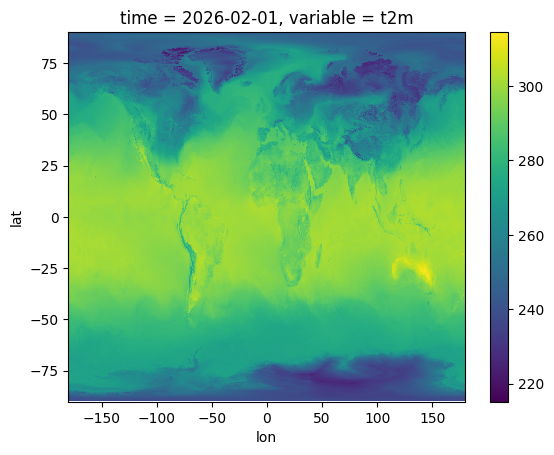

In [6]:
mo_data = MetOfficeAtlasSource()
mo_t2m = mo_data(
    time = datetime(2026,2,1),
    variable = ['t2m']
).pipe(roll_lon)
mo_t2m.squeeze().plot()

In [7]:
all_vars_mo = mo_data(
    time = datetime(2026,2,2),
    variable = atlas_input
).pipe(roll_lon).assign_coords(source='mo')

all_vars_era = ARCO()(
    time = datetime(2021,2,2),
    variable = atlas_input
).pipe(roll_lon).assign_coords(source='era5')


Fetching met-office-global-deterministic-pressure:   0%|          | 0/70 [00:00<?, ?it/s]

Fetching met-office-global-deterministic-pressure: 100%|██████████| 70/70 [00:16<00:00,  4.18it/s]


2026-02-23 11:11:20.077 | DEBUG    | src.metoffice_ocean:_download:199 - MetOfficeASDI: cache hit bd957b254433a18e_level1_coupled_orca025_GL4_TEM_b20260202_dm20260202.nc


Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/azureuser/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x76847e786bc0> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-9' coro=<_async_in_context.<locals>.run_in_context() done, defined at /mnt/tmp/uv_env/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-10' coro=<Kernel.shell_main() running at /mnt/tmp/uv_env/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /mnt/tmp/uv_env/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/mnt/tmp/uv_env/lib/python3.12/site-packages/multistorageclient/cache.py:33: RuntimeWarning: coroutine 

2026-02-23 11:11:21.079 | DEBUG    | earth2studio.data.arco:_async_init:125 - Using Multi-Storage Client for ARCO data access


Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/azureuser/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x76847e786bc0> is already entered
Task was destroyed but it is pending!
task: <Task pending name='Task-19' coro=<_async_in_context.<locals>.run_in_context() done, defined at /mnt/tmp/uv_env/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-20' coro=<Kernel.shell_main() running at /mnt/tmp/uv_env/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /mnt/tmp/uv_env/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/home/azureuser/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/json/decoder.py

2026-02-23 11:11:22.536 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: v10m at 2021-02-02T00:00:00
2026-02-23 11:11:22.537 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: u925 at 2021-02-02T00:00:00
2026-02-23 11:11:22.538 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: v250 at 2021-02-02T00:00:00
2026-02-23 11:11:22.539 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: z50 at 2021-02-02T00:00:00
2026-02-23 11:11:22.540 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: tp at 2021-02-02T00:00:00
2026-02-23 11:11:22.541 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: u500 at 2021-02-02T00:00:00
2026-02-23 11:11:22.543 | DEBUG    | earth2studio.data.arco:fetch_array:289 - Fetching ARCO zarr array for variable: t150 at 2021-02-

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/azureuser/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x76847e786bc0> is already entered
Fetching ARCO data: 100%|██████████| 75/75 [00:04<00:00, 18.12it/s]


In [ ]:
ds = xr.concat([x.to_dataset(dim='variable').squeeze(drop=True) for x in (all_vars_mo, all_vars_era)], dim='source')
ds

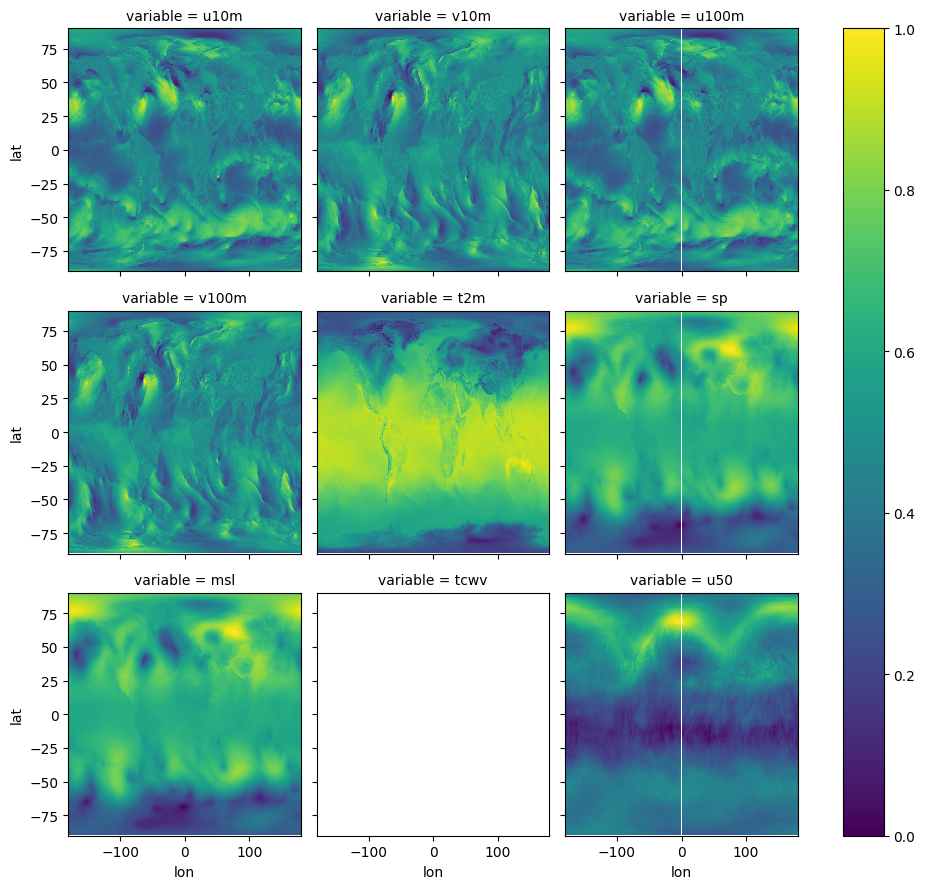

In [21]:
norm = lambda x: (x - x.min(dim=('lat', 'lon'))) / (x.max(dim=('lat', 'lon')) - x.min(dim=('lat', 'lon')))
all_vars_mo.sel(variable=atlas_input[:9]).squeeze(drop=True).pipe(norm).plot.pcolormesh(
    x='lon', y='lat', col='variable', col_wrap=3
)

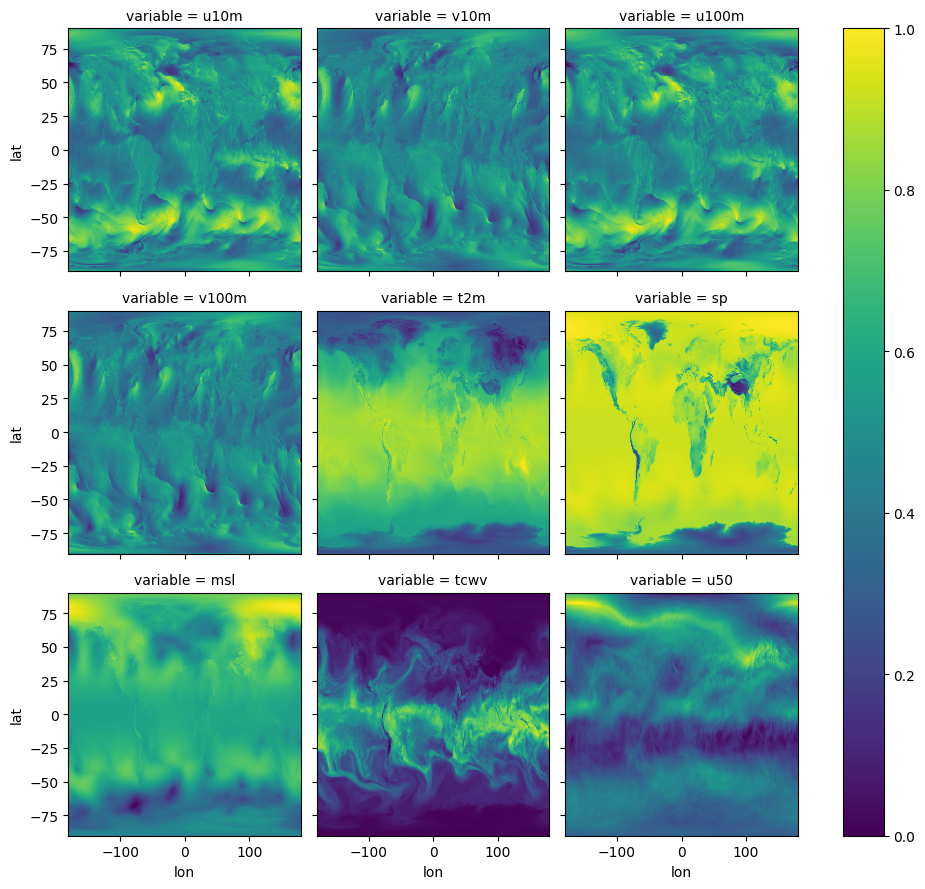

In [18]:
all_vars_era.sel(variable=atlas_input[:9]).squeeze(drop=True).pipe(norm).plot.pcolormesh(
    x='lon', y='lat', col='variable', col_wrap=3
)

2026-02-18 13:45:57.244 | DEBUG    | earth2studio.data.arco:_async_init:125 - Using Multi-Storage Client for ARCO data access


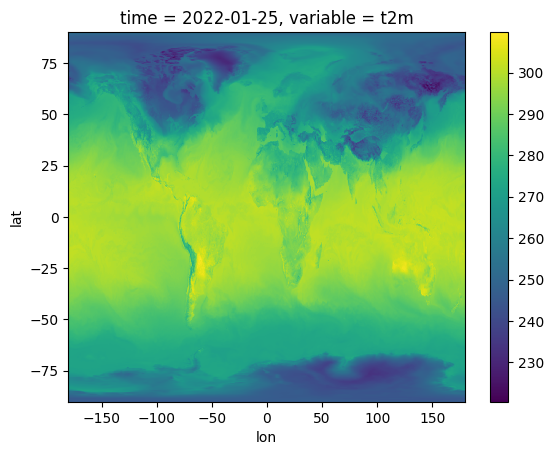

In [3]:
arco = ARCO()
era_t2m = arco(
    time = datetime(2022,1,25),
    variable = ['t2m']
).pipe(roll_lon)
era_t2m.squeeze().plot()

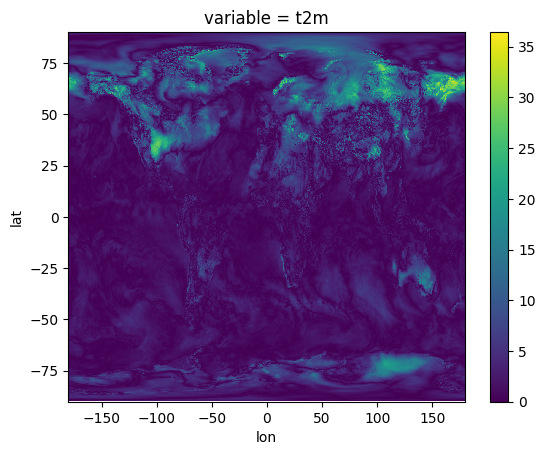

In [4]:
(mo_t2m.squeeze() - era_t2m.squeeze()).pipe(abs).plot()

In [71]:
for x in atlas_input:
    _mo = all_vars_mo.sel(variable=x).squeeze(drop=True)
    _era = all_vars_era.sel(variable=x).squeeze(drop=True)
    print(f"{x}: {_mo.max():.2f} {_era.max():.2f} {(_mo - _era).max():.2f}")
    print(f"{x}: {_mo.min():.2f} {_era.min():.2f} {(_mo - _era).min():.2f}")

u10m: 25.31 19.88 28.81
u10m: -21.42 -22.42 -29.83
v10m: 20.61 25.30 27.00
v10m: -20.86 -22.48 -37.69
u100m: 25.31 25.75 34.03
u100m: -21.42 -29.14 -32.51
v100m: 20.61 33.17 33.33
v100m: -20.86 -28.81 -41.23
t2m: 314.53 311.83 41.25
t2m: 215.11 217.36 -41.21
sp: 104361.00 105544.63 53893.45
sp: 95317.00 48713.55 -5915.81
msl: 104361.00 105530.25 5118.43
msl: 95317.00 94481.56 -5911.28
tcwv: 0.00 74.90 -0.19
tcwv: 0.00 0.19 -74.90
u50: 49.49 47.01 32.25
u50: -26.19 -21.02 -38.56
u100: 58.06 63.86 56.79
u100: -31.94 -45.93 -41.40
u150: 85.20 88.61 56.29
u150: -32.73 -32.02 -59.42
u200: 95.55 102.35 75.37
u200: -23.60 -28.80 -64.69
u250: 104.79 95.96 74.29
u250: -27.70 -29.58 -79.70
u300: 103.31 93.24 78.05
u300: -40.16 -38.24 -81.88
u400: 76.05 80.41 58.87
u400: -33.74 -30.06 -69.75
u500: 65.93 58.87 50.15
u500: -35.49 -27.58 -59.33
u600: 52.66 49.59 45.50
u600: -26.56 -27.59 -53.13
u700: 41.49 46.13 40.94
u700: -25.96 -29.98 -53.64
u850: 37.59 35.76 44.76
u850: -31.13 -38.00 -49.40
u925

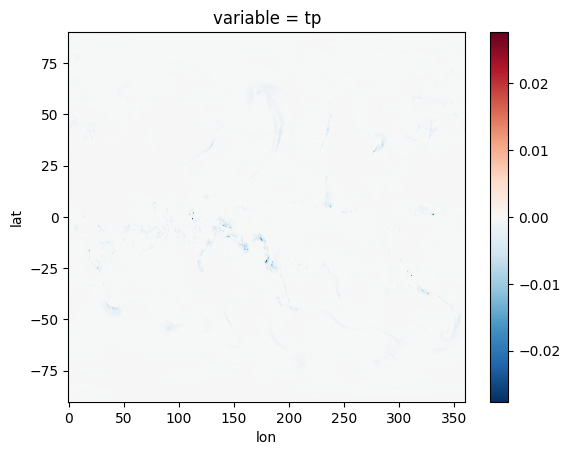

In [67]:
(_mo - _era).plot()

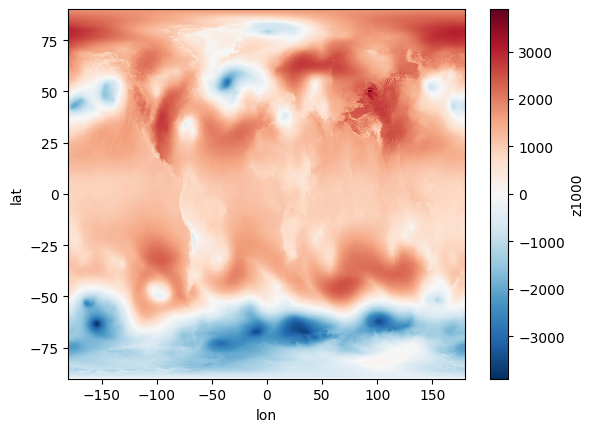

In [70]:
ds.z1000.plot()